In [7]:
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import trimesh
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [8]:
# ── config ────────────────────────────────────────────────────────────────────
CANONICAL = Path("/media/yaplab2/HDD Storage/wenhao/AneuG/dataset/canonical/Sidewall")

# Reorder detected loops to your preferred semantic order.
# RANK[i] = which raw-detected loop becomes opening i in the final list.
# Run the visualisation first, then adjust RANK and re-run if the order is wrong.
RANK = [0, 1]

In [9]:
# ── load meshes ───────────────────────────────────────────────────────────────
mesh         = trimesh.load(CANONICAL / "mesh.obj",         process=False)
mesh_trimmed = trimesh.load(CANONICAL / "mesh_trimmed.obj", process=False)

print(f"mesh.obj         {mesh.vertices.shape[0]:5d} verts  {mesh.faces.shape[0]:5d} faces")
print(f"mesh_trimmed.obj {mesh_trimmed.vertices.shape[0]:5d} verts  {mesh_trimmed.faces.shape[0]:5d} faces")

mesh.obj          2590 verts   5176 faces
mesh_trimmed.obj  2224 verts   4374 faces


In [10]:
# ── detect boundary loops in mesh_trimmed.obj ─────────────────────────────────
def find_boundary_loops(faces):
    """Return list of vertex-index arrays, one per boundary loop."""
    edge_count = Counter(
        tuple(sorted(e))
        for f in faces
        for e in [(f[0], f[1]), (f[1], f[2]), (f[2], f[0])]
    )
    boundary_edges = [(a, b) for (a, b), c in edge_count.items() if c == 1]

    adj = defaultdict(list)
    for a, b in boundary_edges:
        adj[a].append(b)
        adj[b].append(a)

    visited, loops = set(), []
    for start in list(adj):
        if start in visited:
            continue
        loop, cur, prev = [start], start, None
        visited.add(start)
        while True:
            nxt = next((v for v in adj[cur] if v != prev and v not in visited), None)
            if nxt is None:
                break
            loop.append(nxt)
            visited.add(nxt)
            prev, cur = cur, nxt
        loops.append(np.array(loop))
    return loops

loops_trimmed = find_boundary_loops(mesh_trimmed.faces)
print(f"Found {len(loops_trimmed)} boundary loops: sizes {[len(l) for l in loops_trimmed]}")

Found 2 boundary loops: sizes [37, 37]


In [11]:
# ── map trimmed-mesh loop indices → mesh.obj vertex indices ───────────────────
# mesh_trimmed shares exact vertex positions with mesh.obj
tree = cKDTree(mesh.vertices)

def loop_in_full_mesh(loop_idx_trimmed):
    loop_verts = mesh_trimmed.vertices[loop_idx_trimmed]     # [K, 3]
    dists, full_idx = tree.query(loop_verts, k=1)
    assert dists.max() < 1e-6, f"Non-matching vertex (max dist {dists.max():.2e})"
    return full_idx

# apply RANK to reorder loops to preferred semantic order
openings = [loop_in_full_mesh(loops_trimmed[r]) for r in RANK]

for i, idx in enumerate(openings):
    centroid = mesh.vertices[idx].mean(0)
    print(f"Opening {i}:  {len(idx):3d} verts   centroid = [{centroid[0]:.3f}, {centroid[1]:.3f}, {centroid[2]:.3f}]")

Opening 0:   37 verts   centroid = [-0.617, 1.778, -3.700]
Opening 1:   37 verts   centroid = [-1.303, 0.945, 4.060]


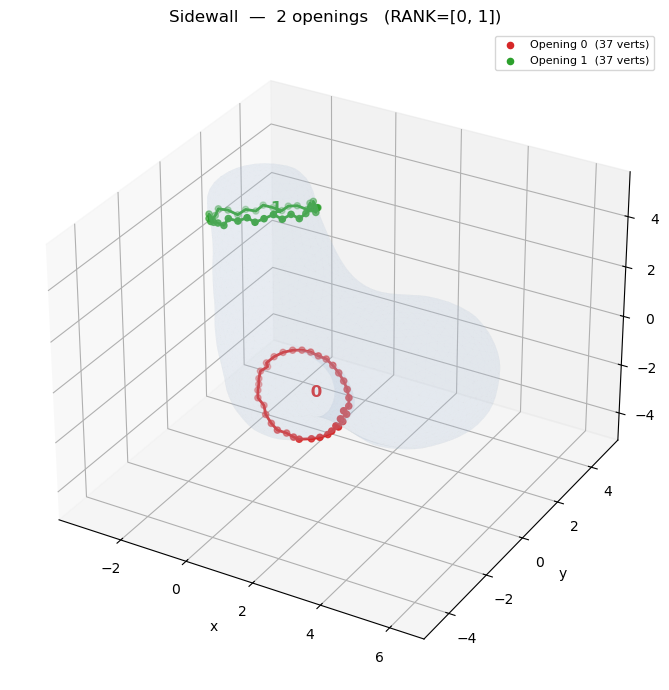

In [12]:
# ── visualise mesh.obj + opening loops ────────────────────────────────────────
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")

verts, faces = mesh.vertices, mesh.faces
tri = Poly3DCollection(verts[faces], alpha=0.12, linewidth=0, facecolor="lightsteelblue")
ax.add_collection3d(tri)

colors = ["tab:red", "tab:green", "tab:orange", "tab:purple"]
for i, idx in enumerate(openings):
    pts    = verts[idx]                           # [K, 3]
    c      = colors[i % len(colors)]
    closed = np.vstack([pts, pts[[0]]])           # close the loop for plotting
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
               s=20, color=c, label=f"Opening {i}  ({len(idx)} verts)", zorder=5)
    ax.plot(closed[:, 0], closed[:, 1], closed[:, 2], color=c, linewidth=2)
    cx, cy, cz = pts.mean(0)
    ax.text(cx, cy, cz, f" {i}", fontsize=12, color=c, fontweight="bold")

# equal axes
lo, hi = verts.min(0), verts.max(0)
r, mid = (hi - lo).max() / 2, (lo + hi) / 2
ax.set_xlim(mid[0]-r, mid[0]+r)
ax.set_ylim(mid[1]-r, mid[1]+r)
ax.set_zlim(mid[2]-r, mid[2]+r)

ax.set_title(f"{CANONICAL.name}  —  {len(openings)} openings   (RANK={RANK})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

In [13]:
# ── save ──────────────────────────────────────────────────────────────────────
# Format for MultiCanonicalGHDReconstruct.compute_branch_directions():
#   num_openings  — scalar int64, number of openings
#   indices_0..N  — int64 arrays of vertex indices into mesh.obj, one per opening
#                   ordered according to RANK above
save_path = CANONICAL / "openings.npz"
np.savez(
    save_path,
    num_openings=np.array(len(openings), dtype=np.int64),
    **{f"indices_{i}": idx.astype(np.int64) for i, idx in enumerate(openings)},
)
print(f"Saved → {save_path}")
print(f"  num_openings = {len(openings)}")
for i, idx in enumerate(openings):
    print(f"  indices_{i}: {len(idx)} verts   centroid = {mesh.vertices[idx].mean(0).round(3)}")

Saved → /media/yaplab2/HDD Storage/wenhao/AneuG/dataset/canonical/Sidewall/openings.npz
  num_openings = 2
  indices_0: 37 verts   centroid = [-0.617  1.778 -3.7  ]
  indices_1: 37 verts   centroid = [-1.303  0.945  4.06 ]


In [ ]:
import torch
file = '/media/yaplab2/HDD Storage/wenhao/AneuG/checkpoints/centreline_fitting/stable/ANSYS_UNIGE_09.pth'
checkpoint = torch.load(file)


[tensor([[ 0.2587, -0.1917, -0.0496],
        [ 0.2622, -0.1923, -0.0496],
        [ 0.2657, -0.1930, -0.0496],
        ...,
        [ 1.5036, -0.6730, -0.1012],
        [ 1.5056, -0.6751, -0.1028],
        [ 1.5076, -0.6772, -0.1043]]), tensor([[-0.3112, -0.0289,  0.2527],
        [-0.3116, -0.0285,  0.2549],
        [-0.3120, -0.0281,  0.2572],
        ...,
        [-0.1423,  0.5304,  0.9897],
        [-0.1417,  0.5327,  0.9908],
        [-0.1411,  0.5350,  0.9919]]), tensor([[ 0.1697,  0.1933, -0.0091],
        [ 0.1697,  0.1950, -0.0079],
        [ 0.1698,  0.1967, -0.0067],
        ...,
        [-0.6213,  0.5835,  0.8704],
        [-0.6218,  0.5842,  0.8731],
        [-0.6222,  0.5849,  0.8757]])]


/tmp/ipykernel_3016127/1452100200.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(file)
